In [2]:
import os
from datetime import datetime, timedelta
import pandas as pd
import sqlalchemy
import matplotlib.pyplot as plt
eng = sqlalchemy.create_engine("sqlite:///earthquake_data.db")


--- Daily Summary Data ---


,event_timestamp,event_count,significant_events
0,2026-04-18-13,8,0


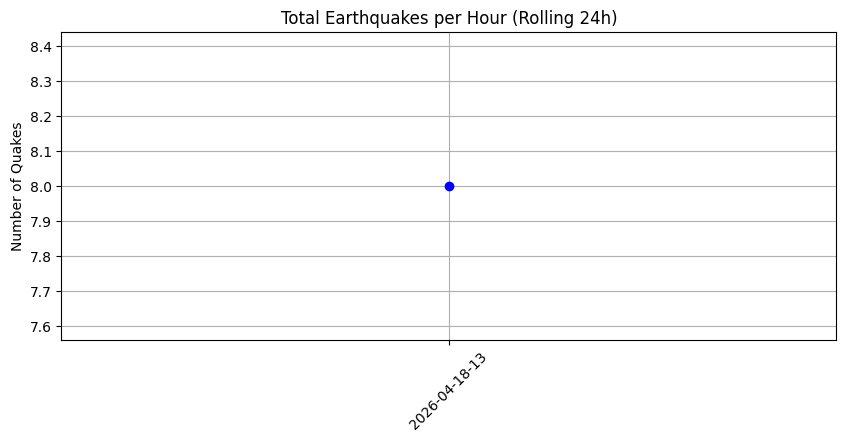

In [ ]:
query_daily = """
    SELECT event_timestamp, event_count, significant_events 
    FROM gold_daily_event_summary 
    ORDER BY event_timestamp ASC;
"""

df_daily = pd.read_sql(query_daily, eng)

print("--- Daily Summary Data ---")
display(df_daily.tail())

plt.figure(figsize=(10, 4))
plt.plot(df_daily['event_timestamp'], df_daily['event_count'], marker='o', color='blue')
plt.title("Total Earthquakes per Hour (Rolling 24h)")
plt.xticks(rotation=45)
plt.ylabel("Number of Quakes")
plt.grid(True)
plt.show()

--- Magnitude Distribution Data ---


,band,event_count
0,<2,8


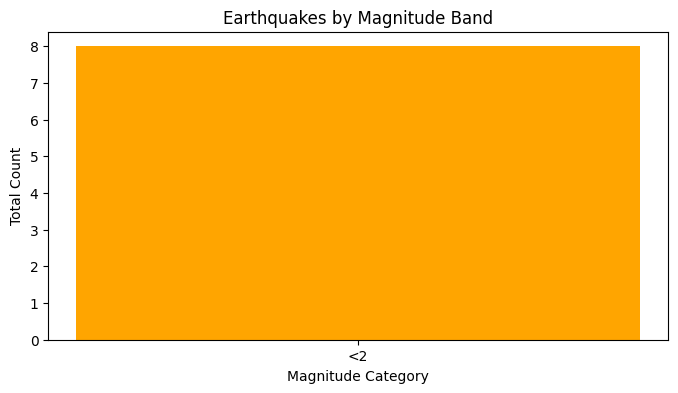

In [5]:
query_bands = """
    SELECT band, event_count 
    FROM gold_magnitude_distribution 
    ORDER BY band ASC;
"""

df_bands = pd.read_sql(query_bands, eng)

print("--- Magnitude Distribution Data ---")
display(df_bands)

plt.figure(figsize=(8, 4))
plt.bar(df_bands['band'].astype(str), df_bands['event_count'], color='orange')
plt.title("Earthquakes by Magnitude Band")
plt.xlabel("Magnitude Category")
plt.ylabel("Total Count")
plt.show()

In [6]:
query_region = """
    SELECT country, event_count, avg_magnitude, max_magnitude
    FROM gold_region_activity
    ORDER BY event_count DESC
    LIMIT 10;
"""

df_region = pd.read_sql(query_region, eng)

print("--- Top 10 Most Active Regions ---")
display(df_region)

--- Top 10 Most Active Regions ---


,country,event_count,avg_magnitude,max_magnitude
0,US,8,1.16875,1.87
